# Task 2: Feature Extraction



In [30]:
import sys
sys.path.append('..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Task 2 — Feature Extraction (ملفاتنا)
from src.features.tfidf import (
    build_tfidf, transform_tfidf,
    save_vectorizer, get_top_terms
)
from src.features.word2vec import (
    build_word2vec, transform_word2vec,
    save_word2vec, get_similar_words
)

sns.set_theme()
os.makedirs('../src/features', exist_ok=True)
os.makedirs('../src/figures',  exist_ok=True)

print('All imports successful.')

All imports successful.


In [31]:
# البيانات دي اتعملت في Task 1 (preprocessing)
data = pd.read_csv('../data/processed/clean_reviews.csv')

print(f'Dataset shape : {data.shape}')
print(f'Columns       : {list(data.columns)}')
print(f'\nSentiment distribution:')
print(data['Sentiment'].value_counts())
print('0 = Negative  |  1 = Positive')

data.head(3)

Dataset shape : (20170, 6)
Columns       : ['Country', 'Rating', 'Review Title', 'Review Text', 'Sentiment', 'Full Review']

Sentiment distribution:
Sentiment
0    14350
1     5820
Name: count, dtype: int64
0 = Negative  |  1 = Positive


,Country,Rating,Review Title,Review Text,Sentiment,Full Review
0,US,1,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...",0,A Store That Doesn't Want to Sell Anything I r...
1,GB,1,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,0,Had multiple orders one turned up and… Had mul...
2,GB,1,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,0,I informed these reprobates I informed these r...


In [32]:
from src.preprocessing.preprocess import preprocess_text

# تطبيق الـ preprocessing على الـ Full Review
print("Applying preprocessing...")
data['Cleaned Review'] = data['Full Review'].apply(preprocess_text)
data['Review Length'] = data['Cleaned Review'].apply(lambda x: len(x.split()))

print(f"Done! Sample:")
print(data['Cleaned Review'].head(3))
X = data['Cleaned Review']
y = data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # بيحافظ على نفس نسبة positive/negative في الـ splits
)

print(f'Train : {len(X_train):,} reviews  ({len(X_train)/len(X):.0%})')
print(f'Test  : {len(X_test):,}  reviews  ({len(X_test)/len(X):.0%})')
print(f'\nTrain class balance: {y_train.value_counts().to_dict()}')

Applying preprocessing...
Done! Sample:
0    store doesnt want sell anything registered web...
1    multiple orders one turned and… multiple order...
2    informed reprobates informed reprobates would ...
Name: Cleaned Review, dtype: str
Train : 16,136 reviews  (80%)
Test  : 4,034  reviews  (20%)

Train class balance: {0: 11480, 1: 4656}


In [33]:
print('Building TF-IDF features...')

# بيتدرب على X_train بس 
vectorizer, X_train_tfidf = build_tfidf(X_train)

# بيحوّل X_test بنفس الـ vectorizer (من غير ما يتدرب عليه) 
X_test_tfidf = transform_tfidf(vectorizer, X_test)

# معلومات عن الـ matrix
total    = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
sparsity = 1 - (X_train_tfidf.nnz / total)
print(f'\nSparsity: {sparsity:.2%} ')

Building TF-IDF features...
[TF-IDF] Vocabulary size : 10,000 terms
[TF-IDF] Train matrix    : (16136, 10000)
[TF-IDF] Transformed matrix: (4034, 10000)

Sparsity: 99.60% 


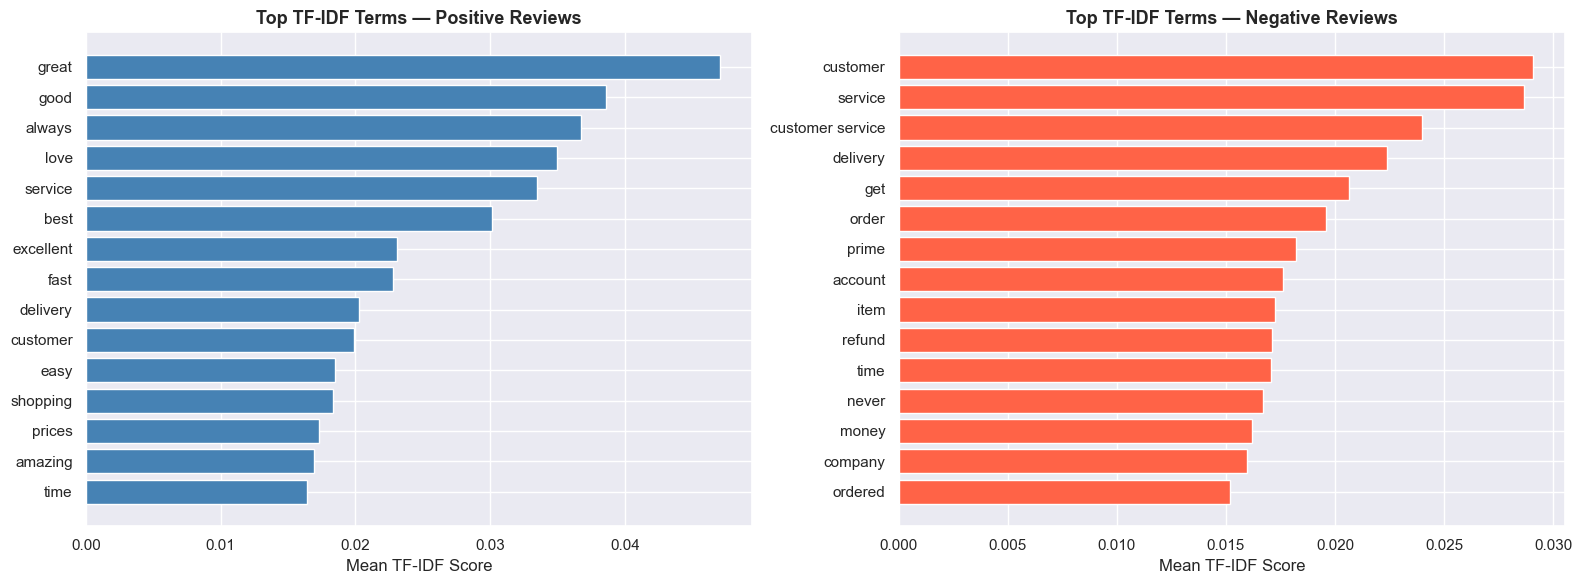

Figure saved


In [34]:
#sentiment
pos_terms, pos_scores = get_top_terms(vectorizer, X_train_tfidf, y_train, sentiment_value=1, top_n=15)
neg_terms, neg_scores = get_top_terms(vectorizer, X_train_tfidf, y_train, sentiment_value=0, top_n=15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(pos_terms[::-1], pos_scores[::-1], color='steelblue')
axes[0].set_title('Top TF-IDF Terms — Positive Reviews', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean TF-IDF Score')

axes[1].barh(neg_terms[::-1], neg_scores[::-1], color='tomato')
axes[1].set_title('Top TF-IDF Terms — Negative Reviews', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean TF-IDF Score')

plt.tight_layout()
plt.savefig('../src/figures/tfidf_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved')

In [35]:
import scipy.sparse as sp

save_vectorizer(vectorizer, path='../outputs/features/tfidf_vectorizer.pkl')

sp.save_npz('../outputs/features/X_train_tfidf.npz', X_train_tfidf)
sp.save_npz('../outputs/features/X_test_tfidf.npz',  X_test_tfidf)

print('TF-IDF artifacts saved ')

[TF-IDF] Vectorizer saved to: ../outputs/features/tfidf_vectorizer.pkl
TF-IDF artifacts saved 


In [36]:
#save_word2vec
print('Training Word2Vec...')

# بيتدرب على X_train بس 
w2v_model = build_word2vec(
    X_train,
    vector_size=100,   # كل كلمة = 100 رقم
    window=5,          # بيشوف 5 كلمات قبل وبعد كل كلمة
    min_count=2,       # يتجاهل الكلمات اللي ظهرت أقل من مرتين
    sg=1,              # Skip-gram
    epochs=10,
    seed=42
)

Training Word2Vec...
[Word2Vec] Vocabulary size     : 14,292 words
[Word2Vec] Embedding dimensions: 100


In [37]:
# بنختبر إن الموديل اتعلم معنى الكلمات صح
for word in ['good', 'bad', 'delivery', 'quality']:
    similar = get_similar_words(w2v_model, word, topn=5)
    if similar:
        print(f"the most similar words to '{word}':")
        for w, score in similar:
            print(f'  {w:<20} {score:.4f}')

the most similar words to 'good':
  good…                0.7357
  excelent             0.6885
  assortment           0.6800
  👍                    0.6789
  great                0.6783
the most similar words to 'bad':
  woww                 0.6396
  uae                  0.6301
  there…               0.6228
  poor                 0.6220
  serviceis            0.6212
the most similar words to 'delivery':
  deliverys            0.7471
  delivery…            0.7356
  noon                 0.7240
  teamed               0.7228
  “guaranteed”         0.7214
the most similar words to 'quality':
  😔                    0.6809
  good…                0.6799
  products…            0.6677
  exceeds              0.6572
  rapidly              0.6514


In [38]:
print('Transforming reviews to Word2Vec embeddings...')

X_train_w2v = transform_word2vec(X_train, w2v_model)
X_test_w2v  = transform_word2vec(X_test,  w2v_model)

Transforming reviews to Word2Vec embeddings...
[Word2Vec] Embedding matrix: (16136, 100)
[Word2Vec] Embedding matrix: (4034, 100)


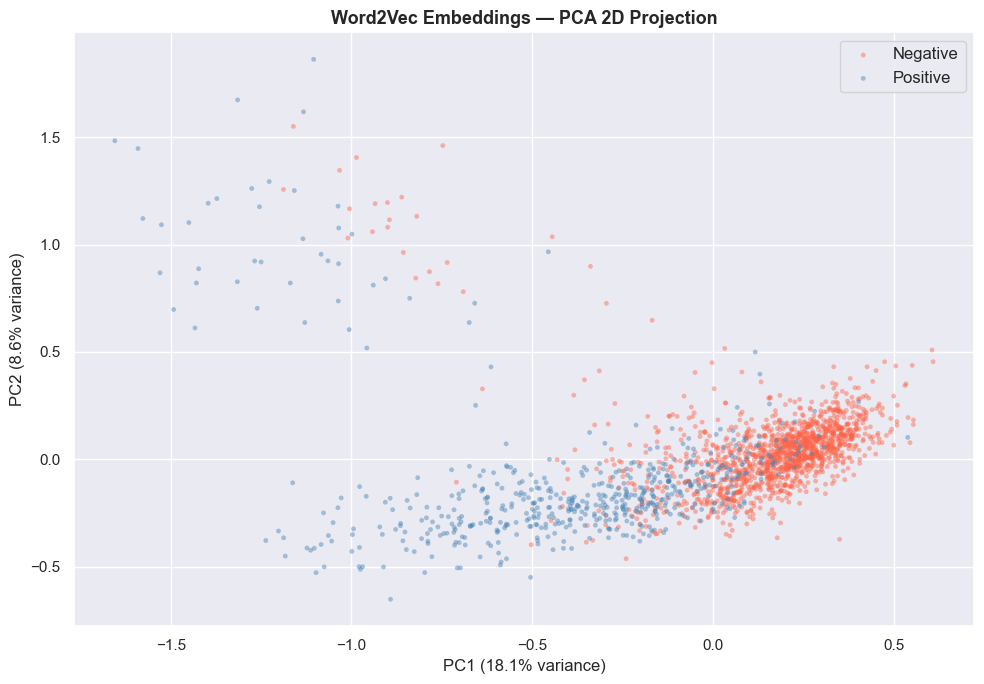

Figure saved 


In [39]:
# Embeddings shape check PCA visualization

sample_size = min(2000, len(X_train_w2v))
idx = np.random.RandomState(42).choice(len(X_train_w2v), sample_size, replace=False)

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(X_train_w2v[idx])
y_sample = y_train.values[idx]

fig, ax = plt.subplots(figsize=(10, 7))
for val, color, label in [(0, 'tomato', 'Negative'), (1, 'steelblue', 'Positive')]:
    mask = (y_sample == val)
    ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
               c=color, label=label, alpha=0.45, s=12, edgecolors='none')

ax.set_title('Word2Vec Embeddings — PCA 2D Projection', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('../src/figures/w2v_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ')

In [40]:
save_word2vec(w2v_model, X_train_w2v, X_test_w2v, out_dir='../outputs/features')
print('Word2Vec artifacts saved ')

[Word2Vec] Model and embeddings saved to: ../outputs/features
Word2Vec artifacts saved 


In [41]:
np.save('../outputs/features/y_train.npy', y_train.values)
np.save('../outputs/features/y_test.npy',  y_test.values)

# حفظ النصوص المقسّمة (هيحتاجها LSTM في Task 3)
splits = pd.DataFrame({
    'split': ['train'] * len(X_train) + ['test'] * len(X_test),
    'text' : list(X_train) + list(X_test),
    'label': list(y_train) + list(y_test)
})
splits.to_csv('../outputs/features/text_splits.csv', index=False)

print('Labels and text splits saved ')

Labels and text splits saved 


In [42]:
summary = pd.DataFrame({
    'Feature Method'     : ['TF-IDF', 'Word2Vec (Avg Pooling)'],
    'Representation'     : ['Sparse (mostly zeros)', 'Dense (all values matter)'],
    'Output Dimensions'  : [X_train_tfidf.shape[1], X_train_w2v.shape[1]],
    'Captures Semantics' : ['No', 'Yes'],
    'Needs Training'     : ['No (statistical)', 'Yes (on train corpus)'],
    'Best Used With'     : ['Logistic Regression / Naive Bayes', 'LSTM / Neural Networks']
})
display(summary)

print('\n=== Saved Artifacts ===')
for f in sorted(os.listdir('../outputs/features')):
    size_kb = os.path.getsize(f'../outputs/features/{f}') / 1024
    print(f'  {f:<35} {size_kb:>8.1f} KB')

,Feature Method,Representation,Output Dimensions,Captures Semantics,Needs Training,Best Used With
0,TF-IDF,Sparse (mostly zeros),10000,No,No (statistical),Logistic Regression / Naive Bayes
1,Word2Vec (Avg Pooling),Dense (all values matter),100,Yes,Yes (on train corpus),LSTM / Neural Networks



=== Saved Artifacts ===
  X_test_tfidf.npz                      1432.9 KB
  X_test_w2v.npy                        3151.7 KB
  X_train_tfidf.npz                     5852.0 KB
  X_train_w2v.npy                      12606.4 KB
  text_splits.csv                       6524.4 KB
  tfidf_vectorizer.pkl                   448.1 KB
  word2vec.model                       11651.0 KB
  y_test.npy                              31.6 KB
  y_train.npy                            126.2 KB


In [43]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

False


AssertionError: Torch not compiled with CUDA enabled